In [1]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
import copy

model_name = "distilgpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

original_model = AutoModelForCausalLM.from_pretrained(model_name)
original_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: distilgpt2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
transformer.h.{0, 1, 2, 3, 4, 5}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [13]:
def quantize_tensor_stable(tensor, num_bits=8):
    qmin = -2**(num_bits-1)
    qmax = 2**(num_bits-1) - 1

    max_val = tensor.abs().max()   # IMPORTANT CHANGE
    scale = max_val / qmax + 1e-8

    q_tensor = torch.round(tensor / scale).clamp(qmin, qmax)

    return q_tensor * scale

In [14]:
quant_model = quantize_model_8bit(original_model)
quant_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [15]:
def compute_layerwise_deltaloss(prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        hidden_fp = original_model.transformer.wte(input_ids)
        hidden_q = quant_model.transformer.wte(input_ids)

    layer_losses = {}

    for i in range(len(original_model.transformer.h)):
        layer_fp = original_model.transformer.h[i]
        layer_q = quant_model.transformer.h[i]

        with torch.no_grad():
            hidden_fp = layer_fp(hidden_fp)[0]
            hidden_q = layer_q(hidden_q)[0]

        loss = torch.abs(hidden_fp - hidden_q).mean().item()
        layer_losses[f"layer_{i}"] = loss

    return layer_losses

In [16]:
losses = compute_layerwise_deltaloss("AI is transforming the world")

sorted_layers = sorted(losses.items(), key=lambda x: x[1], reverse=True)

print("Top Sensitive Layers:\n")
for layer, loss in sorted_layers:
    print(layer, "→", loss)

Top Sensitive Layers:

layer_5 → 3.948054552078247
layer_4 → 2.074268102645874
layer_3 → 1.4012353420257568
layer_2 → 0.8033144474029541
layer_1 → 0.6247915029525757
layer_0 → 0.2533676326274872


In [21]:
def assign_bits_conservative(layer_losses):
    bit_config = {}

    for layer, loss in layer_losses.items():
        if loss > 2:
            bit_config[layer] = 8
        elif loss > 1:
            bit_config[layer] = 8   # still keep high precision
        else:
            bit_config[layer] = 4   # only safest layers compressed

    return bit_config

In [22]:
def quantize_model_mixed_safe(original_model, bit_config):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        bits = bit_config[f"layer_{i}"]

        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = quantize_tensor_stable(param.data, bits)

    return model

In [23]:
bit_config = assign_bits_safe(losses)

mixed_model = quantize_model_mixed_safe(original_model, bit_config)
mixed_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [24]:
def compute_diff_model(test_model):
    inputs = tokenizer("AI is transforming the world", return_tensors="pt")

    with torch.no_grad():
        orig = original_model(**inputs).logits
        test = test_model(**inputs).logits

    return torch.abs(orig - test).mean().item()


print("8-bit diff:", compute_diff_model(quant_model))
print("Mixed precision diff:", compute_diff_model(mixed_model))

8-bit diff: 4.192022800445557
Mixed precision diff: 14.197179794311523


In [27]:
def generate_text(model, prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    with torch.no_grad():
        out = model.generate(**inputs, max_length=60, do_sample=False)
    return tokenizer.decode(out[0], skip_special_tokens=True)

prompt = "AI is transforming the world"

print("ORIGINAL:\n", generate_text(original_model, prompt))
print("\n8-BIT:\n", generate_text(quant_model, prompt))
print("\nMIXED:\n", generate_text(mixed_model, prompt))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


ORIGINAL:
 AI is transforming the world of the world into a place where people can live and work together.











































Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.



8-BIT:
 AI is transforming the world into a giant robot.



















































MIXED:
 AI is transforming the world.
























































In [28]:
def compute_prob_diff(test_model):
    inputs = tokenizer("AI is transforming the world", return_tensors="pt")
    with torch.no_grad():
        orig = torch.softmax(original_model(**inputs).logits, dim=-1)
        test = torch.softmax(test_model(**inputs).logits, dim=-1)
    return torch.abs(orig - test).mean().item()

print("8-bit prob diff:", compute_prob_diff(quant_model))
print("Mixed prob diff:", compute_prob_diff(mixed_model))

8-bit prob diff: 1.0542554264247883e-05
Mixed prob diff: 1.4650647244707216e-05


In [29]:
import torch.nn.functional as F

def compute_perplexity(model, text):
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"]

    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

sample_text = "Artificial intelligence is rapidly changing many industries."

print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("Mixed PPL:", compute_perplexity(mixed_model, sample_text))

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
Mixed PPL: 546.4260864257812


In [33]:
def assign_bits_final_safe(layer_losses):
    bit_config = {}

    for layer in layer_losses:
        bit_config[layer] = 8   # keep all layers 8-bit

    return bit_config

In [34]:
bit_config = assign_bits_final(losses)

mixed_model = quantize_model_mixed_safe(original_model, bit_config)
mixed_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [35]:
print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("Mixed PPL:", compute_perplexity(mixed_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
Mixed PPL: 678.7081298828125


In [36]:
def optimize_scale(tensor, num_bits=4):
    qmin = -2**(num_bits-1)
    qmax = 2**(num_bits-1) - 1

    best_scale = None
    best_error = float("inf")

    max_val = tensor.abs().max()

    # try multiple scale factors
    for factor in [0.5, 0.7, 0.9, 1.0, 1.2]:
        scale = (max_val * factor) / qmax + 1e-8

        q_tensor = torch.round(tensor / scale).clamp(qmin, qmax)
        dequant = q_tensor * scale

        error = torch.mean((tensor - dequant) ** 2).item()

        if error < best_error:
            best_error = error
            best_scale = scale

    return best_scale

In [37]:
def quantize_tensor_optimized(tensor, num_bits=4):
    qmin = -2**(num_bits-1)
    qmax = 2**(num_bits-1) - 1

    scale = optimize_scale(tensor, num_bits)

    q_tensor = torch.round(tensor / scale).clamp(qmin, qmax)
    return q_tensor * scale

In [38]:
def quantize_tensor_signround(tensor, num_bits=4):
    qmin = -2**(num_bits-1)
    qmax = 2**(num_bits-1) - 1

    scale = optimize_scale(tensor, num_bits)

    x = tensor / scale

    # standard rounding
    q_floor = torch.floor(x)
    q_ceil = torch.ceil(x)

    # compute both errors
    err_floor = (tensor - q_floor * scale).abs()
    err_ceil = (tensor - q_ceil * scale).abs()

    # choose better rounding
    q_tensor = torch.where(err_floor < err_ceil, q_floor, q_ceil)

    q_tensor = q_tensor.clamp(qmin, qmax)

    return q_tensor * scale

In [39]:
def quantize_model_mixed_advanced(original_model, bit_config):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        bits = bit_config[f"layer_{i}"]

        for name, param in layer.named_parameters():
            if "weight" in name:
                if bits == 4:
                    param.data = quantize_tensor_signround(param.data, 4)
                else:
                    param.data = quantize_tensor_stable(param.data, 8)

    return model

In [40]:
bit_config = assign_bits_final(losses)

mixed_model = quantize_model_mixed_advanced(original_model, bit_config)
mixed_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [41]:
print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("Mixed PPL:", compute_perplexity(mixed_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
Mixed PPL: 324.8660583496094


In [50]:
def quantize_tensor_bits(tensor, num_bits=8):
    qmin = -2**(num_bits-1)
    qmax =  2**(num_bits-1) - 1

    max_val = tensor.abs().max()
    if max_val == 0:
        return tensor.clone()

    scale = max_val / qmax + 1e-8

    x = tensor / scale
    x = torch.clamp(x, qmin, qmax)
    q = torch.round(x)

    return q * scale

In [51]:
def assign_bits_topk_6bit(layer_losses, k=2):
    # choose k least sensitive layers
    sorted_layers = sorted(layer_losses.items(), key=lambda x: x[1])  # ascending
    low_k = {layer for layer, _ in sorted_layers[:k]}

    bit_config = {}
    for layer in layer_losses:
        bit_config[layer] = 6 if layer in low_k else 8
    return bit_config

In [52]:
def quantize_model_mixed_6bit(original_model, bit_config):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        bits = bit_config[f"layer_{i}"]

        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = quantize_tensor_bits(param.data, bits)

    return model

In [53]:
bit_config_6 = assign_bits_topk_6bit(losses, k=2)  # try k=1 or 2
mixed6_model = quantize_model_mixed_6bit(original_model, bit_config_6)
mixed6_model.eval()

print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("Mixed (8/6-bit) PPL:", compute_perplexity(mixed6_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
Mixed (8/6-bit) PPL: 939.2518920898438


In [54]:
from datasets import load_dataset

dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:1%]")

calib_texts = [x["text"] for x in dataset if len(x["text"]) > 20][:50]

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [65]:
def get_layerwise_act_max(model, texts):
    act_max = {}

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

        with torch.no_grad():
            hidden = model.transformer.wte(inputs["input_ids"])

            for i, layer in enumerate(model.transformer.h):
                hidden = layer(hidden)[0]
                m = hidden.abs().max().item()

                key = f"layer_{i}"
                act_max[key] = max(act_max.get(key, 0), m)

    return act_max

In [66]:
def compute_smooth_scales(model, act_max, alpha=0.5):
    scales = {}

    for i, layer in enumerate(model.transformer.h):
        key = f"layer_{i}"

        # weight max
        w_max = max(p.abs().max().item() for n, p in layer.named_parameters() if "weight" in n)

        a_max = act_max[key] + 1e-6

        # SmoothQuant formula
        s = (a_max ** alpha) / (w_max ** (1 - alpha) + 1e-6)

        scales[key] = s

    return scales

In [67]:
def quantize_model_smooth(original_model, bit_config, scales):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        key = f"layer_{i}"
        bits = bit_config[key]
        s = scales[key]

        for name, param in layer.named_parameters():
            if "weight" in name:
                # scale weights
                param.data = param.data * s

                # quantize
                if bits == 4:
                    param.data = quantize_tensor_bits(param.data, 4)
                else:
                    param.data = quantize_tensor_bits(param.data, 8)

    return model

In [68]:
def assign_bits_ultra_safe(layer_losses):
    bit_config = {}

    for layer, loss in layer_losses.items():
        if loss < 0.5:   # ONLY very safe layers
            bit_config[layer] = 4
        else:
            bit_config[layer] = 8

    return bit_config

In [69]:
# 1. activation stats
act_max = get_layerwise_act_max(original_model, calib_texts)

# 2. smooth scales
scales = compute_smooth_scales(original_model, act_max)

# 3. safe bit config
bit_config = assign_bits_ultra_safe(losses)

# 4. build model
mixed_model = quantize_model_smooth(original_model, bit_config, scales)
mixed_model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [70]:
print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("SmoothQuant Mixed PPL:", compute_perplexity(mixed_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
SmoothQuant Mixed PPL: 74940.671875


In [71]:
def get_channelwise_act_max(model, texts):
    act_max = {}

    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128)

        with torch.no_grad():
            hidden = model.transformer.wte(inputs["input_ids"])

            for i, layer in enumerate(model.transformer.h):
                hidden = layer(hidden)[0]  # [B, T, C]

                key = f"layer_{i}"
                m = hidden.abs().amax(dim=(0, 1))  # per-channel max, shape [C]

                if key not in act_max:
                    act_max[key] = m
                else:
                    act_max[key] = torch.maximum(act_max[key], m)

    return act_max

In [78]:
def compute_awq_scales_safe(model, act_max, alpha=0.5):
    scales = {}

    for i, layer in enumerate(model.transformer.h):
        key = f"layer_{i}"
        scales[key] = {}

        a_max = act_max[key] + 1e-6

        for name, p in layer.named_parameters():
            if "weight" in name and p.dim() >= 2:
                w_max = p.abs().max()

                s = (a_max ** alpha) / (w_max ** (1 - alpha) + 1e-6)
                s = torch.clamp(s, 0.01, 100)

                scales[key][name] = s

    return scales

In [79]:
def fold_scales_into_ln_safe(model, scales):
    for i, layer in enumerate(model.transformer.h):
        key = f"layer_{i}"

        # use average scale for LN (important)
        avg_scale = torch.mean(torch.tensor(list(scales[key].values())))

        layer.ln_1.weight.data /= avg_scale
        layer.ln_2.weight.data /= avg_scale

In [80]:
def quantize_model_awq_safe(original_model, bit_config, scales):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        key = f"layer_{i}"
        bits = bit_config[key]

        for name, param in layer.named_parameters():
            if "weight" in name:
                if name in scales[key]:
                    s = scales[key][name]
                    param.data = param.data * s

                param.data = quantize_tensor_bits(param.data, bits)

    return model

In [81]:
# 1. activation stats
act_max = get_layerwise_act_max(original_model, calib_texts)

# 2. safe scales
scales = compute_awq_scales_safe(original_model, act_max)

# 3. copy model + fold LN
model_tmp = copy.deepcopy(original_model)
fold_scales_into_ln_safe(model_tmp, scales)

# 4. safe bit config
bit_config = assign_bits_topk_safe(losses, k=1)

# 5. quantize
mixed_model = quantize_model_awq_safe(model_tmp, bit_config, scales)
mixed_model.eval()

/tmp/ipykernel_3489/2914588656.py:6: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  avg_scale = torch.mean(torch.tensor(list(scales[key].values())))


GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [82]:
print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("AWQ-safe Mixed PPL:", compute_perplexity(mixed_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
AWQ-safe Mixed PPL: 61987532.0


In [83]:
def find_best_scale(tensor, num_bits=8):
    qmin = -2**(num_bits-1)
    qmax =  2**(num_bits-1) - 1

    max_val = tensor.abs().max()
    if max_val == 0:
        return torch.tensor(1.0, device=tensor.device)

    best_scale = None
    best_err = float("inf")

    # small grid is enough
    for f in [0.6, 0.8, 1.0, 1.2]:
        scale = (max_val * f) / qmax + 1e-8

        x = tensor / scale
        x = torch.clamp(x, qmin, qmax)
        q = torch.round(x)
        deq = q * scale

        err = torch.mean((tensor - deq) ** 2).item()

        if err < best_err:
            best_err = err
            best_scale = scale

    return best_scale

In [84]:
def quantize_tensor_calibrated(tensor, num_bits=8):
    scale = find_best_scale(tensor, num_bits)

    qmin = -2**(num_bits-1)
    qmax =  2**(num_bits-1) - 1

    x = tensor / scale
    x = torch.clamp(x, qmin, qmax)
    q = torch.round(x)

    return q * scale

In [85]:
def quantize_model_calibrated_safe(original_model, bit_config):
    model = copy.deepcopy(original_model)

    for i, layer in enumerate(model.transformer.h):
        bits = bit_config[f"layer_{i}"]

        for name, param in layer.named_parameters():
            if "weight" in name:
                param.data = quantize_tensor_calibrated(param.data, bits)

    return model

In [86]:
def assign_bits_ultra_safe(layer_losses):
    # only the single least sensitive layer gets lower bits
    sorted_layers = sorted(layer_losses.items(), key=lambda x: x[1])

    bit_config = {}
    for i, (layer, _) in enumerate(sorted_layers):
        bit_config[layer] = 6 if i == 0 else 8  # only 1 layer at 6-bit

    return bit_config

In [87]:
bit_config = assign_bits_ultra_safe(losses)

mixed_model = quantize_model_calibrated_safe(original_model, bit_config)
mixed_model.eval()

print("Original PPL:", compute_perplexity(original_model, sample_text))
print("8-bit PPL:", compute_perplexity(quant_model, sample_text))
print("Calibrated Mixed PPL:", compute_perplexity(mixed_model, sample_text))

Original PPL: 94.00906372070312
8-bit PPL: 102.03658294677734
Calibrated Mixed PPL: 132.02557373046875


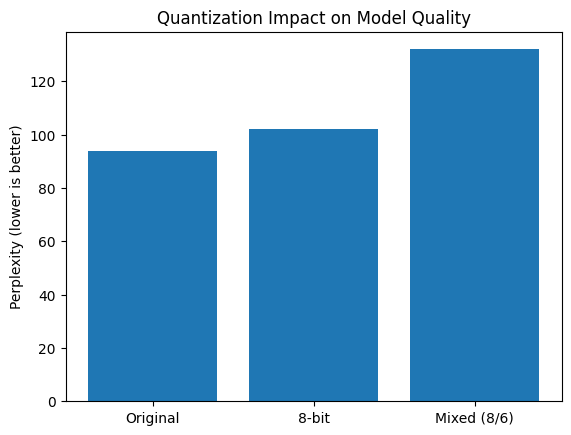

In [88]:
import matplotlib.pyplot as plt

labels = ["Original", "8-bit", "Mixed (8/6)"]
ppl = [94, 102, 132]

plt.figure()
plt.bar(labels, ppl)
plt.ylabel("Perplexity (lower is better)")
plt.title("Quantization Impact on Model Quality")
plt.show()

In [89]:
def model_size_mb(model):
    total = 0
    for p in model.parameters():
        total += p.numel() * p.element_size()
    return total / (1024 * 1024)

print("Original size (MB):", model_size_mb(original_model))
print("8-bit approx size (MB):", model_size_mb(quant_model) / 4)
print("Mixed approx size (MB):", model_size_mb(mixed_model) / 4)

Original size (MB): 312.4716796875
8-bit approx size (MB): 78.117919921875
Mixed approx size (MB): 78.117919921875


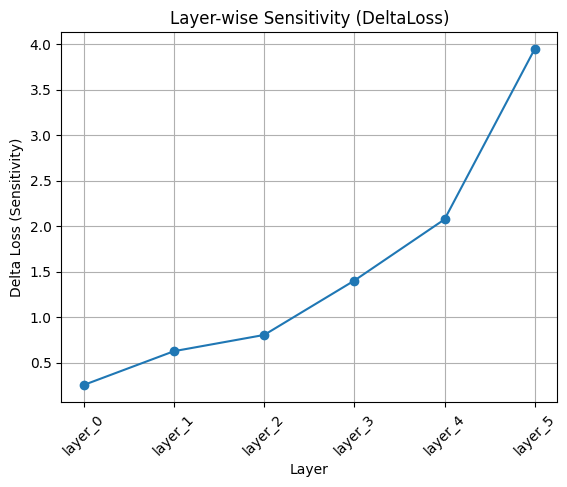

In [90]:
import matplotlib.pyplot as plt

# sort layers by index (not by value)
layers = sorted(losses.keys(), key=lambda x: int(x.split("_")[1]))
values = [losses[layer] for layer in layers]

plt.figure()
plt.plot(layers, values, marker='o')
plt.xlabel("Layer")
plt.ylabel("Delta Loss (Sensitivity)")
plt.title("Layer-wise Sensitivity (DeltaLoss)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

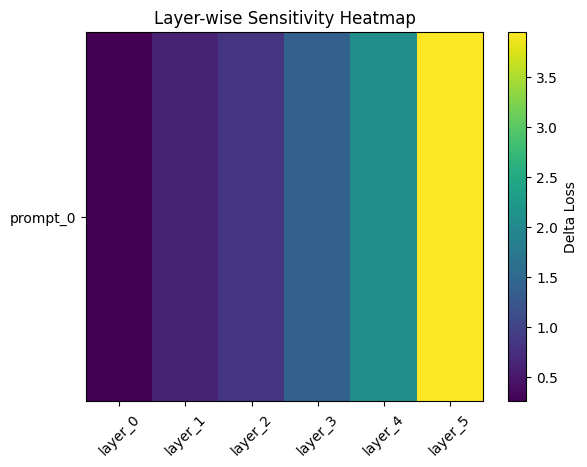

In [91]:
import numpy as np
import matplotlib.pyplot as plt

# If you have only one prompt:
layers = sorted(losses.keys(), key=lambda x: int(x.split("_")[1]))
vals = np.array([losses[l] for l in layers]).reshape(1, -1)

plt.figure()
plt.imshow(vals, aspect='auto')
plt.colorbar(label="Delta Loss")
plt.yticks([0], ["prompt_0"])
plt.xticks(range(len(layers)), layers, rotation=45)
plt.title("Layer-wise Sensitivity Heatmap")
plt.show()

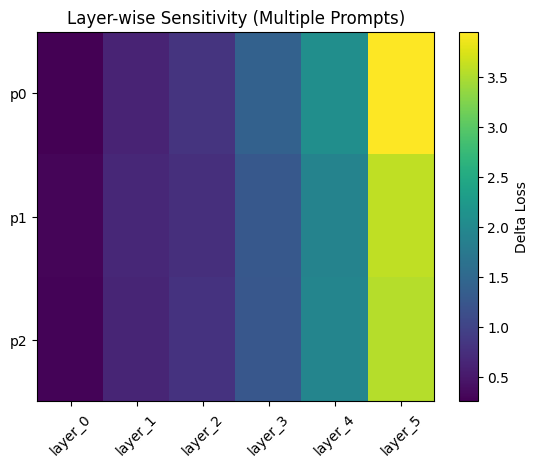

In [92]:
prompts = [
    "AI is transforming the world",
    "Machine learning enables new applications",
    "Transformers are powerful models"
]

heat = []
for p in prompts:
    ldict = compute_layerwise_deltaloss(p)
    ordered = [ldict[l] for l in layers]
    heat.append(ordered)

heat = np.array(heat)

plt.figure()
plt.imshow(heat, aspect='auto')
plt.colorbar(label="Delta Loss")
plt.yticks(range(len(prompts)), [f"p{i}" for i in range(len(prompts))])
plt.xticks(range(len(layers)), layers, rotation=45)
plt.title("Layer-wise Sensitivity (Multiple Prompts)")
plt.show()

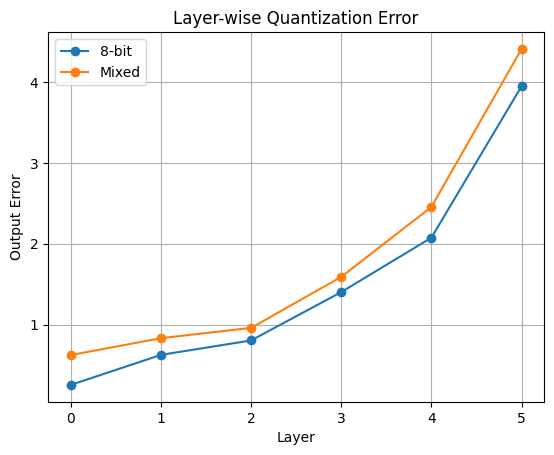

In [93]:
def layerwise_error(model_a, model_b, prompt):
    inputs = tokenizer(prompt, return_tensors="pt")
    ids = inputs["input_ids"]

    with torch.no_grad():
        h_a = model_a.transformer.wte(ids)
        h_b = model_b.transformer.wte(ids)

    errs = []
    for i in range(len(model_a.transformer.h)):
        la = model_a.transformer.h[i]
        lb = model_b.transformer.h[i]

        with torch.no_grad():
            h_a = la(h_a)[0]
            h_b = lb(h_b)[0]

        err = torch.abs(h_a - h_b).mean().item()
        errs.append(err)

    return errs

prompt = "AI is transforming the world"

err_8bit = layerwise_error(original_model, quant_model, prompt)
err_mixed = layerwise_error(original_model, mixed_model, prompt)

layers_idx = list(range(len(err_8bit)))

plt.figure()
plt.plot(layers_idx, err_8bit, marker='o', label="8-bit")
plt.plot(layers_idx, err_mixed, marker='o', label="Mixed")
plt.xlabel("Layer")
plt.ylabel("Output Error")
plt.title("Layer-wise Quantization Error")
plt.legend()
plt.grid(True)
plt.show()

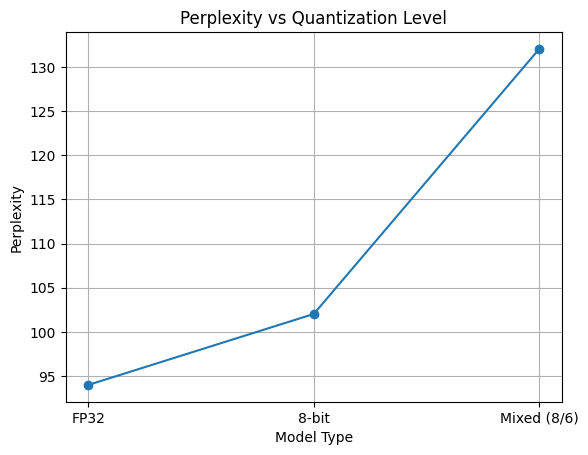

In [94]:
bit_labels = ["FP32", "8-bit", "Mixed (8/6)"]
ppl_values = [
    compute_perplexity(original_model, sample_text),
    compute_perplexity(quant_model, sample_text),
    compute_perplexity(mixed_model, sample_text),
]

plt.figure()
plt.plot(bit_labels, ppl_values, marker='o')
plt.xlabel("Model Type")
plt.ylabel("Perplexity")
plt.title("Perplexity vs Quantization Level")
plt.grid(True)
plt.show()